<a href="https://colab.research.google.com/github/jhamidi1/Data201-Spring/blob/main/Hamidi_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: NYPD Arrest Data Analysis
Jathiya Hamidi

April 2, 2026

# Introduction
This project uses the data from the NYPD, it shows the arrests made (Year to Date) from Data.gov. The dataset includes information about arrests made in New York City during the current year. Each row represents one arrest and includes details like the type of crime, location, time, and basic information about the person arrested. The population of interest in this dataset is people who were arrested in NYC. The data is collected and reviewed every few months, which helps keep it organized and updated.

There are some limitations with this dataset. Since the data is based on police activity, it may not represent all crimes, only the ones that led to arrests. It can also reflect differences in policing across areas. As a result, some groups may be overrepresented in the data due to policing in that area instead of actual crime rates. This suggests the data may contain bias and should be interpreted carefully.

Data citation: New York Police Department. 2026. NYPD Arrest Data (Year to Date). Data.gov.
https://catalog.data.gov/dataset/nypd-arrest-data-year-to-date

# Dataset Structue

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("NYPD_Arrest_Data__Year_to_Date_ (2).csv")
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [6]:
df = df.dropna(subset=["ARREST_BORO", "PERP_SEX"])

In [7]:
df.shape

(278953, 19)

The dataset contains 278953 rows and 19 columns.

In [8]:
df.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

Each row in this dataset represents one arrest made by the New York Police Department in New York City. The dataset includes information about the offense, location, date, and demographic details of the person who was arrested.

In [9]:
table = pd.DataFrame({
    "Name": ["ARREST_DATE", "PERP_SEX", "PERP_RACE", "AGE_GROUP", "ARREST_BORO", "OFNS_DESC"],
    "Definition / Explanation": [
        "Date of the arrest",
        "Sex of the person arrested",
        "Race of the person arrested",
        "Age group of the person arrested",
        "Borough where the arrest occurred",
        "Description of the offense"
    ],
    "Type": ["Categorical", "Categorical", "Categorical", "Categorical", "Categorical", "Categorical"]
})

table

,Name,Definition / Explanation,Type
0,ARREST_DATE,Date of the arrest,Categorical
1,PERP_SEX,Sex of the person arrested,Categorical
2,PERP_RACE,Race of the person arrested,Categorical
3,AGE_GROUP,Age group of the person arrested,Categorical
4,ARREST_BORO,Borough where the arrest occurred,Categorical
5,OFNS_DESC,Description of the offense,Categorical


# Data Analyses

### a. Quantitative Variable (Descriptive)


Research Question: “How does the number of arrests differ across New York City boroughs?”

Why the dataset is appropriate: The dataset is appropriate because it provides real world arrest counts by borough, so it will show a clear and reliable comparison across NYC areas.

**Summary Stats**

In [10]:
arrest_stats = df["ARREST_BORO"].value_counts()
arrest_stats

arrest_stats.describe()

,count
count,5.000000
mean,55790.600000
std,25943.159085
min,11707.000000
25%,58083.000000
50%,62833.000000
75%,66448.000000
max,79882.000000


**Vizualization**

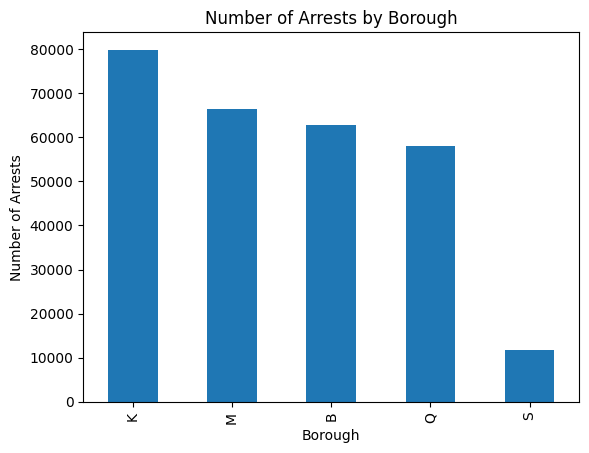

In [11]:
df['ARREST_BORO'].value_counts().plot(kind='bar')
plt.title("Number of Arrests by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")
plt.show()

Data Cleaning: The dataset was cleaned, then the data was then transformed by grouping arrests by borough using value counts, showing a easier comparison across categories.

Measures of Center and Spread: The mean number of arrests across boroughs is approximately 55,790, while the median is 62,833. Which means that most boroughs have high arrest counts. The standard deviation is about 25,943, showing a large spread in the data. The range is also wide, from 11,707 to 79,882.

## b. Categorical Variable

Research Question: How do arrest counts for different offense types compare between male and female perpetrators?

**Summary Stats**

In [12]:
summary_counts = pd.crosstab(df["OFNS_DESC"], df["PERP_SEX"])
summary_counts

PERP_SEX,(null),F,M
OFNS_DESC,,,
(null),11,0,12
ADMINISTRATIVE CODE,95,10,58
ADMINISTRATIVE CODES,3,0,1
ALCOHOLIC BEVERAGE CONTROL LAW,140,35,62
ANTICIPATORY OFFENSES,116,35,117
...,...,...,...
THEFT-FRAUD,182,23,108
UNAUTHORIZED USE OF A VEHICLE,327,23,176
UNDER THE INFLUENCE OF DRUGS,2,0,0


**Vizualization**

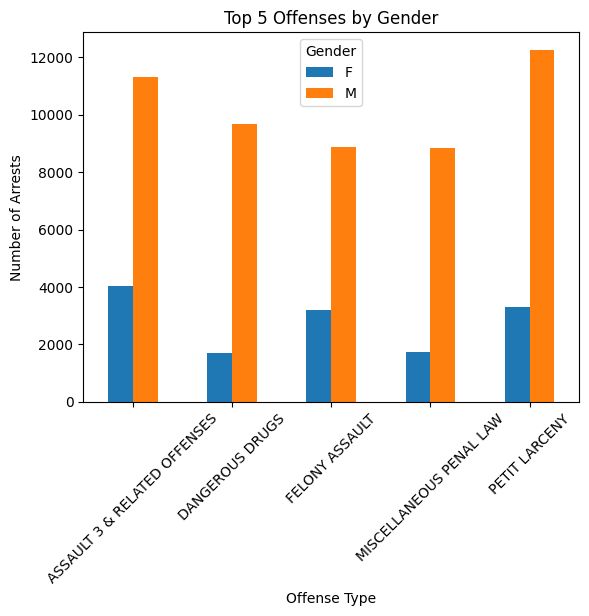

In [13]:
df_clean = df[df["PERP_SEX"].isin(["M", "F"])]

top5 = df_clean["OFNS_DESC"].value_counts().head(5).index
filtered_df = df_clean[df_clean["OFNS_DESC"].isin(top5)]

summary_counts = pd.crosstab(filtered_df["OFNS_DESC"], filtered_df["PERP_SEX"])
summary_counts.plot(kind="bar")

plt.title("Top 5 Offenses by Gender")
plt.xlabel("Offense Type")
plt.ylabel("Number of Arrests")
plt.xticks(rotation=45)
plt.legend(title="Gender")

plt.show()

Data Cleaning: The dataset was cleaned by focusing only on some variables, like the offense type and perpetrator sex. Records with missing or unknown values for gender were excluded to show clear comparisons.

Definition of Levels: The categorical variable PERP_SEX has two levels: Male (M) and Female (F). The variable OFNS_DESC shows different offense categories, like assault, drug-related offenses, and larceny. Each level shows category used to compare arrest counts.

Interpretation of Results: The results show that males have a higher arrest count than females. Both genders have similar patterns of the most common offenses, the frequency for males is consistently much higher. This shows a strong difference in arrest distribution by gender, with males having the majority of arrests in each category.

## c. Relationship Between Variables

Research Question: Which offense types have the largest differences in arrest counts between male and female perpetrators?

Initially, the goal was to compare arrest counts for the different offenses by gender. After looking at the data the focus changed to finding which offenses have the biggest differences between males and females. This better matches what the data shows and makes the results clearer.

Discuss:
There is a relationship between gender and offense type because differnt groups may be involved in different types of crimes more often. The data shows that an association does exist. Males have a higher arrest count than females in every offense type. This shows that even though the type of offense is similar ythere is still a greater frequancy of arrests for males.

## d. Nonparametric Inference

In [18]:
sample_df = df.sample(frac=0.10, random_state=42) # take a random sample of about 10%

sample_df.shape

(27895, 19)

In [19]:
boro_counts_sample = sample_df["ARREST_BORO"].value_counts() # count arrests by borough
boro_counts_sample

,count
ARREST_BORO,
K,7990
M,6644
B,6224
Q,5872
S,1165


In [20]:
boro_counts_sample.median() # median

6224.0

In [21]:
boro_counts_sample.describe() # summary statistics

,count
count,5.000000
mean,5579.000000
std,2594.822537
min,1165.000000
25%,5872.000000
50%,6224.000000
75%,6644.000000
max,7990.000000


A random sample of 10% of the dataset was taken using a random selection method. A nonparametric approach was using the median, because it is less affected by extreme values and also shows a better measure of the typical number of arrests across the boroughs. The results showed a median of 6,224 arrests, with Brooklyn having the highest count (7,990) and Staten Island the lowest (1,165). This shows that arrest activity is unevenly distributed across boroughs.

## Conclusions

The analysis shwos that the arrest counts are not evenly distributed accross NYC boroughs. Brooklyn had the highest counts while Staten Island had the lowest. There is also a clear association between gender and offense type, and males have shown consistantly higher arrest counts than women. Overall these results show that certain areas have higher levels of arrest activity than others.